# Feishu portfolio-management backtest — filter + flat-decay

**Data.** Uses the **same in-sample file** every model was trained on, scored
on its **held-out test split** (the last 15% of each asset's trading days —
the standard train/val/test cut, same split the models were evaluated on
during training). No separate file is required.

**Strategy — filter by predicted class, not a derived score.** Each model
outputs `(P(down), P(flat), P(up)`. The position each day is decided by
**which class the model actually predicts (argmax)** — not by a continuous
`P(up) − P(down)` score:

- predicted **UP**   → target position = **full long** (+1)
- predicted **DOWN** → target position = **full short** (−1)
- predicted **FLAT** (i.e. `P(flat)` is the largest of the three) → **sell
  50% of whatever position you currently hold** (if you have one) — position
  decays toward flat rather than snapping to zero or staying at full size.

Positions are gross-normalised across the day's cross-section (`Σ|w| = 1`)
so the book is comparable in scale across models and days, then costs are
charged on turnover exactly as usual. `score = P(up) − P(down)` is still
computed and reported as the **Information Coefficient** diagnostic, but it
plays **no role in sizing positions** — sizing is driven purely by the
filtered class.

**Benchmark.** An **equal-weighted market index** (long-only, 1/N every asset,
rebalanced daily, same cost model) is computed alongside every model — a
model only adds value if it beats *this*.

> **Caveats.** Cost *model*, not an execution simulation (no market impact,
> no partial fills). The test split is a held-out slice of the *same* file
> the model trained on (chronologically later days, never seen in training),
> not an independently collected period — read **relative rankings across
> models**, not absolute return levels, as the reliable output.

> Run from the **Penny repo root** so `data/stocks/feishu` and `checkpoints/`
> resolve.

## 1. Setup

In [31]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").is_dir():
            return p
    raise RuntimeError(f"could not find Penny repo root above {start}")


REPO = _find_repo_root(Path.cwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))
print("repo root:", REPO)

from stocks.feishu.dataset import LOBDataset  # noqa: E402
from stocks.feishu.build import _VAL_CUM, _asset_ranges, _build_feature_matrix  # noqa: E402
from stocks.feishu.labels import compute_forward_returns  # noqa: E402
from models.deeplob import DeepLOB  # noqa: E402
from models.ctabl import CTABL  # noqa: E402
from models.dla import DLA  # noqa: E402
from models.tlob import TLOB  # noqa: E402
from models.linvar import LinVAR  # noqa: E402
from models.logreg import LogReg  # noqa: E402
from models.jumpgatelob import JumpGateLOB  # noqa: E402
from models.alphastablelob import AlphaStableLOB  # noqa: E402

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

repo root: /Users/arshia/Projects/Personal/Penny
device: cpu


## 2. Config & checkpoint registry

`VARIANT` selects which trained (in-sample) runs to load. `SYMBOLS` is the
asset universe the backtest is built over.

In [32]:
BATCH = 256
VARIANT = "20_assets"           # "20_assets" | "all"
TRADING_DAYS = 242               # A-share year, for annualisation
COST_BPS = 10.0                  # round-trip cost charged on daily turnover
FLAT_DECAY = 0.50                # fraction of an existing position sold when predicted FLAT

# high-volume asset groups (from the volume / trading-uniformity analysis)
UNIFORM_10 = ["A002059", "A001750", "A000863", "A000369", "A001402",
              "A001472", "A001351", "A001438", "A000956", "A000613"]
NOISY_10 = ["A002000", "A000295", "A001748", "A002042", "A000400",
            "A000875", "A000452", "A001208", "A002142", "A001663"]
SYMBOLS = UNIFORM_10 + NOISY_10

MODELS = {
    "logreg": LogReg, "linvar": LinVAR, "deeplob": DeepLOB, "ctabl": CTABL,
    "dla": DLA, "tlob": TLOB, "jumpgatelob": JumpGateLOB,
    "alphastablelob": AlphaStableLOB,
}
DISPLAY = {m: m for m in MODELS}
CKPT_ROOT = REPO / "checkpoints" / "stocks" / "feishu"


def discover_checkpoints():
    found = {}
    for tag in MODELS:
        d = CKPT_ROOT / tag
        if not d.exists():
            continue
        runs = sorted(
            p for p in d.iterdir()
            if p.is_dir() and p.name.endswith(VARIANT) and (p / "best.pt").exists()
        )
        if runs:
            found[tag] = runs[-1]
    return found


CHECKPOINTS = discover_checkpoints()
print(f"variant={VARIANT}  |  {len(SYMBOLS)} assets  |  discovered checkpoints:")
for tag in MODELS:
    hit = CHECKPOINTS.get(tag)
    print(f"  {tag:<16} {'OK ' + hit.name if hit else '-- missing'}")

variant=20_assets  |  20 assets  |  discovered checkpoints:
  logreg           OK logreg_ofi_20_assets
  linvar           OK linvar_ofi_20_assets
  deeplob          OK deeplob_ofi_20_assets
  ctabl            OK ctabl_ofi_20_assets
  dla              OK dla_ofi_20_assets
  tlob             OK tlob_ofi_20_assets
  jumpgatelob      OK jumpgatelob_levy_ofi_20_assets
  alphastablelob   OK alphastablelob_joint_a1.5_ofi_20_assets


## 3. Build the backtest frame

Reuses `_build_feature_matrix` (the exact feature pipeline every model was
trained on) on the **same in-sample file**, and locally attaches each
window's **entry date** and **continuous forward return** — the same
`(close_{t+1} − vwap_t)/|vwap_t|` quantity the label thresholds, recomputed
directly from the daily file so the backtest is self-contained. The test
slice (last 15% of each asset's trading days, via `_VAL_CUM`) mirrors
`build_datasets_multi` exactly, so this is the same held-out period the
models were evaluated on during training.

In [33]:
def build_backtest_frame(config, data_dir, symbols):
    """(test_ds, bt_df): bt_df row i <-> the i-th window a shuffle=False loader
    over test_ds yields, with columns asset_idx/asset/date/fwd_ret/label."""
    T = config["T_past"]
    feat, row_labels, row_asset, nf, ordered_syms = _build_feature_matrix(
        config, data_dir, symbols
    )

    root = Path(data_dir).resolve()
    daily = pd.read_parquet(root / config.get("daily_file", "daily_data_in_sample.parquet"))
    daily = daily.rename(columns={"trade_day_id": "date"})
    daily["date"] = daily["date"].astype(str)
    daily = daily[daily["asset_id"].isin(set(ordered_syms))]
    per_sym = {s: g.sort_values("date").reset_index(drop=True)
              for s, g in daily.groupby("asset_id", sort=True)}

    n_rows = len(row_asset)
    row_date = np.empty(n_rows, dtype=object)
    row_fwd = np.full(n_rows, np.nan, dtype=np.float64)
    ptr = 0
    for sym in ordered_syms:  # same per-asset order as _build_feature_matrix
        g = per_sym[sym]
        nd = len(g)
        row_date[ptr:ptr + nd] = g["date"].to_numpy()
        row_fwd[ptr:ptr + nd] = compute_forward_returns(g).to_numpy()
        ptr += nd
    assert ptr == n_rows, f"row layout mismatch: {ptr} vs {n_rows}"

    rows = []
    for lo, hi in _asset_ranges(row_asset):
        starts = [s for s in range(lo, hi - T) if row_labels[s + T] >= 0]
        if not starts:
            continue
        n_val = int(_VAL_CUM * len(starts))
        for s in starts[n_val:]:  # test slice, same cut as build_datasets_multi
            drow = s + T
            rows.append({
                "start": s, "asset_idx": int(row_asset[s]),
                "asset": ordered_syms[int(row_asset[s])],
                "date": row_date[drow], "fwd_ret": float(row_fwd[drow]),
                "label": int(row_labels[drow]),
            })
    bt_df = pd.DataFrame(rows)
    test_ds = LOBDataset(feat, bt_df["start"].to_numpy(np.int64), row_labels, T,
                         row_asset=row_asset)
    return test_ds, bt_df


# base config shared by every checkpoint variant (T_past/alpha/n_features identical)
assert CHECKPOINTS, "no checkpoints discovered -- check VARIANT/CKPT_ROOT"
_base = torch.load(next(iter(CHECKPOINTS.values())) / "best.pt",
                   map_location=DEVICE, weights_only=False)["config"].copy()
_base["batch_size"] = BATCH
DATA_DIR = _base["data_dir"]
print(f"T_past={_base['T_past']}  alpha={_base['alpha']}  data_dir={DATA_DIR}")

TEST_DS, BT = build_backtest_frame(_base, DATA_DIR, SYMBOLS)
print(f"test windows: {len(TEST_DS)}  |  trading days: {BT['date'].nunique()}  "
      f"({BT['date'].min()} -> {BT['date'].max()})")
BT.head()

2026-07-20 16:25:26.888 | INFO     | stocks.feishu.build:_build_feature_matrix:144 - building feishu features (RAM) mode=OFI nf=259


T_past=50  alpha=0.015  data_dir=data/stocks/feishu


2026-07-20 16:26:12.521 | INFO     | stocks.feishu.build:_build_feature_matrix:254 - feishu features built (in RAM): 9,680 rows × 259 feat


test windows: 1300  |  trading days: 65  (D419 -> D483)


,start,asset_idx,asset,date,fwd_ret,label
0,368,0,A002059,D419,-0.0090,1
1,369,0,A002059,D420,0.0133,1
2,370,0,A002059,D421,0.0339,2
3,371,0,A002059,D422,0.0176,2
4,372,0,A002059,D423,0.0120,1


## 4. Score every model

`pred` (argmax class, 0=down/1=flat/2=up) drives position sizing; `score`
(`P(up) − P(down)`) is retained purely for the IC diagnostic.

In [34]:
@torch.no_grad()
def score_windows(model):
    model.eval()
    loader = DataLoader(TEST_DS, batch_size=BATCH, shuffle=False)
    scores, preds = [], []
    for b in loader:
        p = Fn.softmax(model.predict(b, DEVICE), dim=1).cpu().numpy()
        scores.append(p[:, 2] - p[:, 0])
        preds.append(p.argmax(1))
    return np.concatenate(scores), np.concatenate(preds)


SCORES = {}
for tag, cls in MODELS.items():
    hit = CHECKPOINTS.get(tag)
    if not hit:
        print(f"  {tag:<16} -- no checkpoint, skipped")
        continue
    ckpt = torch.load(hit / "best.pt", map_location=DEVICE, weights_only=False)
    model = cls(ckpt["config"]).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    s, p = score_windows(model)
    SCORES[tag] = (s, p)
    up_frac, dn_frac, fl_frac = (p == 2).mean(), (p == 0).mean(), (p == 1).mean()
    print(f"  {tag:<16} pred mix: up={up_frac:.0%} down={dn_frac:.0%} flat={fl_frac:.0%}")
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
print(f"\nscored {len(SCORES)} models")

  logreg           pred mix: up=30% down=32% flat=38%
  linvar           pred mix: up=18% down=23% flat=59%
  deeplob          pred mix: up=0% down=0% flat=100%
  ctabl            pred mix: up=10% down=11% flat=80%
  dla              pred mix: up=0% down=0% flat=100%
  tlob             pred mix: up=82% down=0% flat=18%
  jumpgatelob      pred mix: up=8% down=21% flat=71%
  alphastablelob   pred mix: up=16% down=19% flat=65%

scored 8 models


## 5. Portfolio construction — filter + flat-decay

Positions persist across days (the decay rule only makes sense relative to
yesterday's holding): predicted UP/DOWN sets the position to full long/short;
predicted FLAT decays whatever is currently held by `FLAT_DECAY` (50%).

In [35]:
def filter_flat_decay_portfolio(bt, pred, score, cost_bps=COST_BPS, flat_decay=FLAT_DECAY):
    """Filter-based long/flat/short strategy using the model's PREDICTED CLASS
    directly (argmax of P(down), P(flat), P(up)) -- not a derived score.

      predicted UP (2)   -> target position = +1  (full long)
      predicted DOWN (0) -> target position = -1  (full short)
      predicted FLAT (1) -> target position = previous position * (1 - flat_decay)
                            i.e. sell `flat_decay` (50%) of any existing position

    `score` is carried through only to report the cross-sectional IC
    diagnostic; it plays no role in sizing. Positions are gross-normalised
    (Σ|w| = 1) each day; cost is charged on turnover.
    """
    df = bt.assign(pred=pred, score=score).dropna(subset=["fwd_ret"])
    daily, prev_w, pos = [], pd.Series(dtype=float), {}
    for d in sorted(df["date"].unique()):
        g = df[df["date"] == d]
        cls = g.set_index("asset")["pred"]
        r = g.set_index("asset")["fwd_ret"]
        s = g.set_index("asset")["score"]
        raw = {}
        for a, c in cls.items():
            prior = pos.get(a, 0.0)
            if c == 2:                                    # predicted UP
                raw[a] = 1.0
            elif c == 0:                                   # predicted DOWN
                raw[a] = -1.0
            else:                                           # predicted FLAT
                raw[a] = prior * (1.0 - flat_decay)         # sell 50% of any existing position
            pos[a] = raw[a]
        w = pd.Series(raw)
        gross = w.abs().sum()
        if gross > 0:
            w = w / gross
        r_gross = float((w * r).sum())
        idx = w.index.union(prev_w.index)
        turnover = float(
            (w.reindex(idx, fill_value=0.0) - prev_w.reindex(idx, fill_value=0.0))
            .abs().sum()
        )
        r_net = r_gross - 0.5 * (cost_bps / 1e4) * turnover
        ic = (float(pd.Series(s.values).corr(pd.Series(r.values), method="spearman"))
              if len(s) >= 3 else np.nan)
        daily.append({"date": d, "gross": r_gross, "net": r_net,
                      "turnover": turnover, "ic": ic, "n": len(g)})
        prev_w = w
    return pd.DataFrame(daily)


def perf(daily):
    if daily.empty:
        return {}
    net = daily["net"].to_numpy()
    sd = net.std(ddof=1)
    cum = np.cumsum(net)
    dd = float((np.maximum.accumulate(cum) - cum).max())
    return {
        "days": len(net),
        "ann_return_%": net.mean() * TRADING_DAYS * 100,
        "ann_vol_%": sd * np.sqrt(TRADING_DAYS) * 100,
        "sharpe": (net.mean() / sd * np.sqrt(TRADING_DAYS)) if sd > 0 else np.nan,
        "max_dd_%": dd * 100,
        "hit_%": (net > 0).mean() * 100,
        "turnover": daily["turnover"].mean(),
        "mean_IC": daily["ic"].mean(),
        "net_bp/day": net.mean() * 1e4,
    }


CURVES, ROWS = {}, []
for tag, (score, pred) in SCORES.items():
    daily = filter_flat_decay_portfolio(BT, pred, score)
    CURVES[tag] = daily
    ROWS.append({"model": DISPLAY[tag], **perf(daily)})
    print(f"  {tag:<16} Sharpe={perf(daily)['sharpe']:+.2f}")

  logreg           Sharpe=-6.04
  linvar           Sharpe=-0.03
  deeplob          Sharpe=+nan
  ctabl            Sharpe=+2.30
  dla              Sharpe=+nan
  tlob             Sharpe=-2.44
  jumpgatelob      Sharpe=+0.45
  alphastablelob   Sharpe=+0.36


## 6. Equal-weighted market index (benchmark)

Long-only, 1/N in every asset in the universe, rebalanced daily, same cost
model — the passive baseline every model must beat.

In [36]:
def equal_weight_index(bt, cost_bps=COST_BPS):
    """Passive benchmark: long-only, equal-weight (1/N) every asset in the
    universe each day, rebalanced daily, same turnover-based cost model as
    the model portfolios. No IC (there is no cross-sectional signal to score)."""
    df = bt.dropna(subset=["fwd_ret"])
    daily, prev = [], pd.Series(dtype=float)
    for d in sorted(df["date"].unique()):
        g = df[df["date"] == d]
        r = g.set_index("asset")["fwd_ret"]
        w = pd.Series(1.0 / len(r), index=r.index)         # equal weight, long-only
        r_gross = float((w * r).sum())
        idx = w.index.union(prev.index)
        turnover = float(
            (w.reindex(idx, fill_value=0.0) - prev.reindex(idx, fill_value=0.0))
            .abs().sum()
        )
        r_net = r_gross - 0.5 * (cost_bps / 1e4) * turnover
        daily.append({"date": d, "gross": r_gross, "net": r_net,
                      "turnover": turnover, "ic": np.nan, "n": len(g)})
        prev = w
    return pd.DataFrame(daily)


BENCH_TAG = "equal_weight_index"
CURVES[BENCH_TAG] = equal_weight_index(BT)
ROWS.append({"model": BENCH_TAG, **perf(CURVES[BENCH_TAG])})
summary = pd.DataFrame(ROWS).set_index("model").sort_values("sharpe", ascending=False)
print(f"  {BENCH_TAG:<16} Sharpe={perf(CURVES[BENCH_TAG])['sharpe']:+.2f}  "
      f"(passive long-only benchmark)")

  equal_weight_index Sharpe=-2.51  (passive long-only benchmark)


## 7. Results

In [37]:
print(f"=== summary (sorted by net Sharpe, {COST_BPS:.0f}bp cost, "
      f"{int(FLAT_DECAY * 100)}% flat-decay) ===")
display(summary.style.background_gradient(cmap="RdYlGn", subset=["sharpe", "mean_IC"])
        .format({"days": "{:.0f}", "ann_return_%": "{:.1f}", "ann_vol_%": "{:.1f}",
                 "sharpe": "{:.2f}", "max_dd_%": "{:.1f}", "hit_%": "{:.0f}",
                 "turnover": "{:.2f}", "mean_IC": "{:.3f}", "net_bp/day": "{:.2f}"}))

=== summary (sorted by net Sharpe, 10bp cost, 50% flat-decay) ===


,days,ann_return_%,ann_vol_%,sharpe,max_dd_%,hit_%,turnover,mean_IC,net_bp/day
model,,,,,,,,,
ctabl,65,61.1,26.5,2.30,10.8,54,1.02,-0.029,25.26
jumpgatelob,65,13.3,29.7,0.45,17.9,58,0.29,0.035,5.49
alphastablelob,65,10.0,28.0,0.36,11.7,52,0.41,0.019,4.15
linvar,65,-0.5,18.1,-0.03,9.5,49,1.00,-0.038,-0.19
tlob,65,-61.9,25.3,-2.44,17.5,40,0.24,0.057,-25.57
equal_weight_index,65,-66.0,26.3,-2.51,18.9,37,0.02,nan,-27.29
logreg,65,-89.8,14.9,-6.04,26.6,32,0.99,-0.035,-37.12
deeplob,65,0.0,0.0,nan,0.0,0,0.00,0.019,0.00
dla,65,0.0,0.0,nan,0.0,0,0.00,0.106,0.00


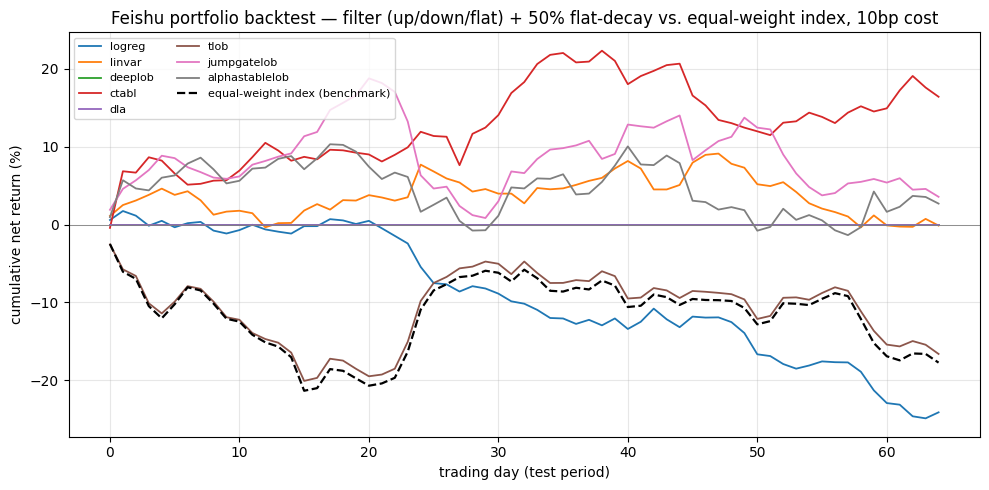

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap("tab10")
i = 0
for tag, daily in CURVES.items():
    if tag == BENCH_TAG:
        continue
    ax.plot(np.arange(len(daily)), np.cumsum(daily["net"]) * 100,
            lw=1.3, color=cmap(i % 10), label=DISPLAY[tag])
    i += 1
ax.plot(np.arange(len(CURVES[BENCH_TAG])), np.cumsum(CURVES[BENCH_TAG]["net"]) * 100,
        "k--", lw=1.6, label="equal-weight index (benchmark)")
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("trading day (test period)")
ax.set_ylabel("cumulative net return (%)")
ax.set_title(f"Feishu portfolio backtest — filter (up/down/flat) + "
             f"{int(FLAT_DECAY * 100)}% flat-decay vs. equal-weight index, "
             f"{COST_BPS:.0f}bp cost")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Reading the results

- **`mean_IC`** is a diagnostic only (score is not used for sizing here) — it
  still tells you whether the model's *confidence* is directionally correct,
  even though positions are driven by the discrete predicted class.
- **`equal_weight_index`** is the passive long-only benchmark. A model that
  doesn't beat it on Sharpe/return isn't adding value over simply holding the
  universe — check this row first before crediting any model with skill.
- **`turnover`** reflects how often the model flips between up/down/flat
  predictions on the test split, plus the decay-driven partial unwinds; high
  turnover with low Sharpe means the model is trading a lot for little.
- The test split is a **held-out slice of the same file** the model trained
  on (chronologically later days, never seen during training or selection) —
  not an independently collected period, so treat this as a sanity check on
  generalisation within the same regime, not a true out-of-time stress test.
- Re-run with a different `COST_BPS` or `FLAT_DECAY` (§2) to see how sensitive
  the ranking is — a ranking that flips at a slightly higher cost or a
  different decay fraction is not a robust ranking.